# 05 — Individual PV-Tendency Terms & Bootstrap Significance

This notebook projects **8 individual** PV-tendency terms onto the four-basis decomposition
(basis from **dh−1**, predictive framing) and uses **bootstrap resampling** for confidence
intervals and significance testing.

Terms: dq/dt, −ū q'_x, −v' q̄_y, −ω' q̄_p, Q, Moist div + vert e-e, Rot. eddy, **Tot. div outflow**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.decomposition.basis import PRENORM_PHI1

# ═══════════════════════════════════════════════════════════
#  Projection masking config (toggle on/off)
# ═══════════════════════════════════════════════════════════
USE_SIG_MASK   = True   # zero out non-significant pixels before projection
USE_NEG_PV_MASK = True  # restrict basis to q' < 0 region (mask_negative)

## 1  Discover and load all event files

In [2]:
DATA_ROOT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE = "onset"
DH = 0
SMOOTH_DEG = 3.0
GRID_SP = 1.5

# Basis always from dh-1 (predictive framing)
DH_BASIS = max(DH - 1, -13)

sign = "+" if DH >= 0 else ""
npz_dir = f"{DATA_ROOT}/{STAGE}/dh={sign}{DH}"
npz_files = sorted(glob.glob(os.path.join(npz_dir, "track_*.npz")))

sign_b = "+" if DH_BASIS >= 0 else ""
npz_dir_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{DH_BASIS}"
npz_files_b = sorted(glob.glob(os.path.join(npz_dir_b, "track_*.npz")))

print(f"Stage: {STAGE}   DH={DH} ({len(npz_files)} files)   "
      f"DH_BASIS={DH_BASIS} ({len(npz_files_b)} files)   "
      f"Smoothing: {SMOOTH_DEG}°")

Stage: onset   DH=0 (1260 files)   DH_BASIS=-1 (1260 files)   Smoothing: 3.0°


In [3]:
from zipfile import BadZipFile

def load_event(path):
    """Load an NPZ file and return a dict (None if corrupt/incomplete)."""
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None

def _load_all(file_list, label=""):
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(load_event, file_list))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ {label}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good

# Load events at DH (fields to project)
events = _load_all(npz_files, f"dh={DH}")
print(f"dh={DH}: {len(events)} events, shape={events[0]['pv_anom'].shape}")

# Load events at DH-1 (for basis construction)
events_basis = _load_all(npz_files_b, f"dh={DH_BASIS}")
print(f"dh={DH_BASIS} (basis): {len(events_basis)} events")

X_rel = events[0]["X_rel"]
Y_rel = events[0]["Y_rel"]
x_rel = X_rel[0, :]
y_rel = Y_rel[:, 0]

dh=0: 1260 events, shape=(29, 49)
dh=-1 (basis): 1260 events


## 2  Compute composite-mean basis fields (from dh−1)

In [4]:
# Average PV anomaly and its derivatives from dh-1 events (predictive framing)
pv_anom_mean = np.nanmean([e["pv_anom"] for e in events_basis], axis=0)
pv_dx_mean   = np.nanmean([e["pv_anom_dx"] for e in events_basis], axis=0)
pv_dy_mean   = np.nanmean([e["pv_anom_dy"] for e in events_basis], axis=0)

basis = compute_orthogonal_basis(
    pv_anom_mean, pv_dx_mean, pv_dy_mean,
    x_rel, y_rel,
    mask_negative=USE_NEG_PV_MASK,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print(f"Composite basis (from dh={DH_BASIS}) norms:",
      {k: f"{v:.4e}" for k, v in basis.norms.items()})
print(f"  mask_negative={USE_NEG_PV_MASK}  USE_SIG_MASK={USE_SIG_MASK}")

Composite basis (from dh=-1) norms: {'beta': '6.6119e+02', 'ax': '8.9056e+02', 'ay': '9.0170e+02', 'gamma': '4.8447e+02'}
  mask_negative=True  USE_SIG_MASK=True


## 3  Define individual RHS terms

In [5]:
# Term name → callable(event_dict) → 2-D field
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":        lambda e: e["pv_anom_dt"] + e["pv_bar_dt"],
    r"$-\bar{u}\,q'_x$":                  lambda e: -e["u_bar_pv_anom_dx"],
    r"$-v'\,\bar{q}_y$":                  lambda e: -e["v_anom_pv_bar_dy"],
    r"$-\omega\,\bar{q}_p$":             lambda e: -(e["w_anom_pv_bar_dp"]
                                                       + e["w_bar_pv_bar_dp"]),
    r"$Q$":                                lambda e: e["Q"],
    r"Moist div":                       lambda e: -(e["u_div_moist_pv_anom_dx"]
                                                       + e["v_div_moist_pv_anom_dy"]),
    r"Dry div":                       lambda e: -(e["u_div_dry_pv_anom_dx"]
                                                       + e["v_div_dry_pv_anom_dy"]),
    r"$-\omega_m\,q'_p$":                         lambda e: -(e["w_moist_pv_anom_dp"]),
    r"Rot. eddy":                          lambda e: -(e["u_rot_pv_anom_dx"]
                                                       + e["v_rot_pv_anom_dy"]),
    # r"Tot. div outflow":                   lambda e: -(e["u_div_pv_anom_dx"]
    #                                                    + e["v_div_pv_anom_dy"]),
}

TERM_NAMES = list(TERMS.keys())
print("Terms:", TERM_NAMES)

Terms: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}\\,q'_x$", "$-v'\\,\\bar{q}_y$", '$-\\omega\\,\\bar{q}_p$', '$Q$', 'Moist div', 'Dry div', "$-\\omega_m\\,q'_p$", 'Rot. eddy']


## 4  Project composite-mean terms onto dh−1 basis

In [6]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# ── Bootstrap field helper (for sig_mask) ──
def bootstrap_field(events_list, field_func, n_boot=1000, alpha=0.05, seed=42):
    """Composite mean + bootstrap CI → (mean, sig_mask)."""
    stack = np.array([field_func(e) for e in events_list])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)
    lo = np.nanpercentile(boot, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask

# ── Composite-mean projection of each term ──
# If USE_SIG_MASK: compute composite sig_mask per term, zero non-sig pixels
term_coefs = {}
term_sig_masks = {}
for name, func in TERMS.items():
    if USE_SIG_MASK:
        fld_mean, sig_m = bootstrap_field(events, func)
        term_sig_masks[name] = sig_m
        fld_masked = np.where(sig_m, fld_mean, 0.0)
        fld_s = smooth(fld_masked)
    else:
        fld_mean = np.nanmean([func(e) for e in events], axis=0)
        fld_s = smooth(fld_mean)
    p = project_field(fld_s, basis)
    term_coefs[name] = {k: p[k] for k in ["beta", "ax", "ay", "gamma"]}
    print(f"{name:30s}  β={p['beta']:.3e}  αx={p['ax']:.3f}  "
          f"αy={p['ay']:.3f}  γ={p['gamma']:.3e}")
print(f"\n  [USE_SIG_MASK={USE_SIG_MASK}]")

$\mathrm{d}q/\mathrm{d}t$       β=3.120e-06  αx=5.418  αy=2.414  γ=-1.913e+05
$-\bar{u}\,q'_x$                β=9.395e-10  αx=16.698  αy=-0.383  γ=-2.348e+06
$-v'\,\bar{q}_y$                β=5.440e-07  αx=-7.565  αy=0.272  γ=1.453e+06
$-\omega\,\bar{q}_p$            β=6.635e-07  αx=-4.718  αy=1.668  γ=1.484e+06
$Q$                             β=-4.520e-07  αx=-0.382  αy=0.035  γ=1.218e+05
Moist div                       β=8.807e-07  αx=-0.852  αy=0.094  γ=-1.221e+04
Dry div                         β=5.496e-07  αx=0.553  αy=-0.224  γ=-2.007e+04
$-\omega_m\,q'_p$               β=-8.322e-07  αx=0.844  αy=-0.365  γ=-1.485e+05
Rot. eddy                       β=1.248e-06  αx=0.862  αy=0.798  γ=-2.311e+05

  [USE_SIG_MASK=True]


## 5  Bootstrap resampling for significance

In [7]:
N_BOOT = 1000
rng = np.random.default_rng(42)
n_events = len(events)

def bootstrap_term(name, func, n_boot=N_BOOT):
    """Bootstrap the projected coefficients for one term.

    If USE_SIG_MASK: per-event field is masked by the composite sig_mask
    (same approach as notebook 07's bootstrap_project).
    """
    # Get sig_mask for this term (compute if not already cached)
    if USE_SIG_MASK:
        if name in term_sig_masks:
            sig_m = term_sig_masks[name]
        else:
            _, sig_m = bootstrap_field(events, func)
            term_sig_masks[name] = sig_m

    # Per-event projections (dh=DH fields onto dh-1 basis)
    per_event = []
    for e in events:
        raw = func(e)
        if USE_SIG_MASK:
            raw = np.where(sig_m, raw, 0.0)
        field_s = smooth(raw)
        p = project_field(field_s, basis)
        per_event.append({k: p[k] for k in ["beta", "ax", "ay", "gamma"]})

    per_event_arr = {k: np.array([pe[k] for pe in per_event])
                     for k in ["beta", "ax", "ay", "gamma"]}

    # Bootstrap
    boot = {k: np.empty(n_boot) for k in ["beta", "ax", "ay", "gamma"]}
    for b in range(n_boot):
        idx = rng.integers(0, n_events, size=n_events)
        for k in boot:
            boot[k][b] = per_event_arr[k][idx].mean()

    return boot

print(f"Running bootstrap (USE_SIG_MASK={USE_SIG_MASK})...")
boot_results = {}
for name, func in TERMS.items():
    boot_results[name] = bootstrap_term(name, func)
    lo, hi = np.nanpercentile(boot_results[name]["beta"], [2.5, 97.5])
    sig = "***" if lo * hi > 0 else "n.s."
    print(f"  {name:30s}  β 95% CI: [{lo:.3e}, {hi:.3e}]  {sig}")

Running bootstrap (USE_SIG_MASK=True)...
  $\mathrm{d}q/\mathrm{d}t$       β 95% CI: [2.821e-06, 3.423e-06]  ***
  $-\bar{u}\,q'_x$                β 95% CI: [-3.558e-07, 3.772e-07]  n.s.
  $-v'\,\bar{q}_y$                β 95% CI: [3.351e-07, 7.478e-07]  ***
  $-\omega\,\bar{q}_p$            β 95% CI: [4.271e-07, 9.044e-07]  ***
  $Q$                             β 95% CI: [-4.895e-07, -4.148e-07]  ***
  Moist div                       β 95% CI: [8.062e-07, 9.563e-07]  ***
  Dry div                         β 95% CI: [4.235e-07, 6.739e-07]  ***
  $-\omega_m\,q'_p$               β 95% CI: [-9.124e-07, -7.463e-07]  ***
  Rot. eddy                       β 95% CI: [1.082e-06, 1.410e-06]  ***


## 6  Visualise bootstrap results

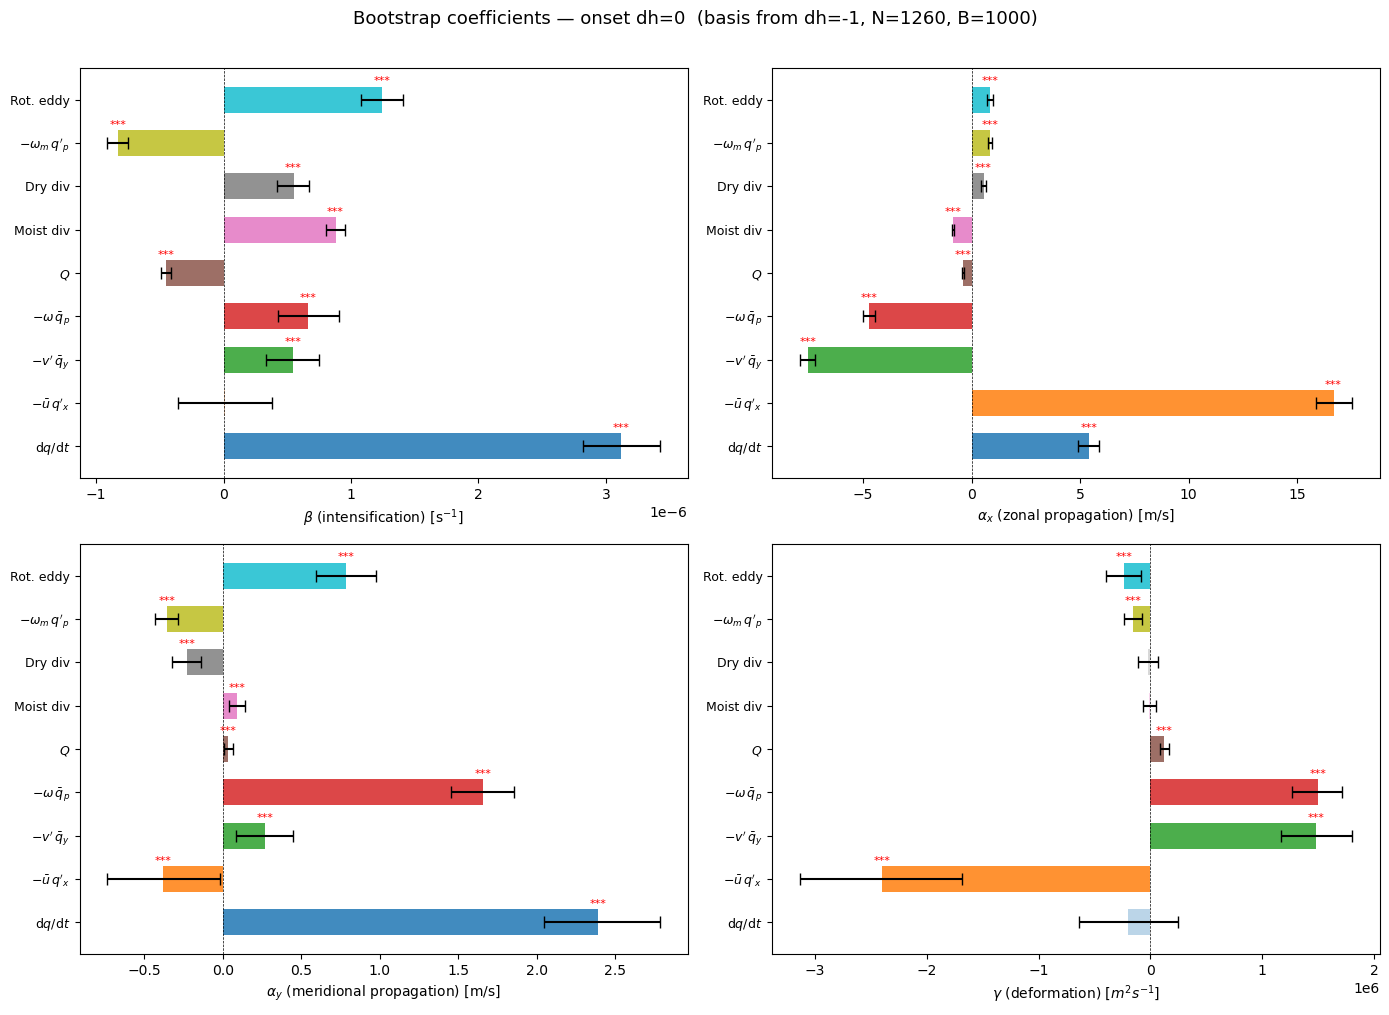

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
coef_names = ["beta", "ax", "ay", "gamma"]
coef_labels = [r"$\beta$ (intensification) [s$^{-1}$]",
               r"$\alpha_x$ (zonal propagation) [m/s]",
               r"$\alpha_y$ (meridional propagation) [m/s]",
               r"$\gamma$ (deformation) [$m^2s^{-1}$]"]

n_terms = len(TERMS)
colors = plt.cm.tab10(np.linspace(0, 1, n_terms))

for ax, cname, clabel in zip(axes.flat, coef_names, coef_labels):
    for i, (tname, bdata) in enumerate(boot_results.items()):
        vals = bdata[cname]
        mean = vals.mean()
        lo, hi = np.nanpercentile(vals, [2.5, 97.5])
        sig = lo * hi > 0  # CI excludes zero?

        ax.barh(i, mean, xerr=[[mean - lo], [hi - mean]],
                color=colors[i],
                alpha=0.85 if sig else 0.3,
                capsize=4, height=0.6)
        if sig:
            ax.text(mean, i + 0.35, "***", ha="center", fontsize=8, color="red")

    ax.set_yticks(range(n_terms))
    ax.set_yticklabels(TERM_NAMES, fontsize=9)
    ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.set_xlabel(clabel, fontsize=10)

fig.suptitle(f"Bootstrap coefficients — {STAGE} dh={DH}  "
             f"(basis from dh={DH_BASIS}, N={n_events}, B={N_BOOT})",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Summary

- **8 individual PV-tendency terms** are projected onto the four-basis decomposition:
  dq/dt, −ū q'_x, −v' q̄_y, −ω' q̄_p, Q, Moist div + vert e-e, Rot. eddy, Tot. div outflow.
- Basis built from **dh−1** composite mean (predictive framing), 6° Gaussian smoothing.
- **Bootstrap resampling** (N=1000) provides 95 % confidence intervals;
  bars are opaque when the CI excludes zero (significant at p < 0.05).
- **Data**: `composite_blocking_tempest/onset`.